In [1]:
# Import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')


**Task 1 — Data Loading & Exploration**

In [5]:
# Load the dataset (first 5000 rows)
df = pd.read_csv("Reviews.csv", nrows=5000)

In [6]:
# Display the first 10 rows
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [7]:
# Display total no of rows & columns
print(f"Total rows    : {df.shape[0]}")
print(f"Total columns : {df.shape[1]}")

Total rows    : 5000
Total columns : 10


In [9]:
print()

Dataset Shape: 5000 rows × 10 columns


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      5000 non-null   int64 
 1   ProductId               5000 non-null   object
 2   UserId                  5000 non-null   object
 3   ProfileName             5000 non-null   object
 4   HelpfulnessNumerator    5000 non-null   int64 
 5   HelpfulnessDenominator  5000 non-null   int64 
 6   Score                   5000 non-null   int64 
 7   Time                    5000 non-null   int64 
 8   Summary                 5000 non-null   object
 9   Text                    5000 non-null   object
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


In [11]:
print('Based on the column names and sample data, the column containing the review text is likely "Text".')

Based on the column names and sample data, the column containing the review text is likely "Text".


**Task 2 — Data Cleaning**

In [12]:
# Check for null values in the 'Text' column
initial_rows = df.shape[0]
print(f"Initial number of rows: {initial_rows}")

# Remove rows where 'Text' is null
df.dropna(subset=['Text'], inplace=True)

# Remove rows where 'Text' is an empty string or contains only whitespace
df = df[df['Text'].str.strip() != '']

rows_after_cleaning = df.shape[0]
print(f"Number of rows after removing empty/null text: {rows_after_cleaning}")
print(f"Number of rows removed: {initial_rows - rows_after_cleaning}")

Initial number of rows: 5000
Number of rows after removing empty/null text: 5000
Number of rows removed: 0


In [13]:
# Check for and remove duplicate reviews based on 'Text' and 'Summary'
initial_rows_before_dedup = df.shape[0]
print(f"Initial number of rows before checking for duplicates: {initial_rows_before_dedup}")

df.drop_duplicates(subset=['Text', 'Summary'], inplace=True)

rows_after_dedup = df.shape[0]
print(f"Number of rows after removing duplicates: {rows_after_dedup}")
print(f"Number of duplicate rows removed: {initial_rows_before_dedup - rows_after_dedup}")

Initial number of rows before checking for duplicates: 5000
Number of rows after removing duplicates: 4987
Number of duplicate rows removed: 13


In [14]:
# Keep only 'Text' and 'Score' columns
df_selected = df[['Text', 'Score']]

print("DataFrame after selecting 'Text' and 'Score' columns:")
display(df_selected.head())

DataFrame after selecting 'Text' and 'Score' columns:


,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


**Task 3 — Sentiment Analysis**

In [18]:
!pip install textblob

In [19]:
from textblob import TextBlob

def get_sentiment_polarity(text):
    return TextBlob(text).sentiment.polarity

df_selected['polarity'] = df_selected['Text'].apply(get_sentiment_polarity)

print("DataFrame with sentiment polarity:")
display(df_selected.head())

DataFrame with sentiment polarity:


,Text,Score,polarity
0,I have bought several of the Vitality canned d...,5,0.450000
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333
2,This is a confection that has been around a fe...,4,0.133571
3,If you are looking for the secret ingredient i...,2,0.166667
4,Great taffy at a great price. There was a wid...,5,0.483333


In [20]:
def get_sentiment_label(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df_selected['sentiment'] = df_selected['polarity'].apply(get_sentiment_label)

print("DataFrame with sentiment labels:")
display(df_selected.head())

DataFrame with sentiment labels:


,Text,Score,polarity,sentiment
0,I have bought several of the Vitality canned d...,5,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333,Negative
2,This is a confection that has been around a fe...,4,0.133571,Positive
3,If you are looking for the secret ingredient i...,2,0.166667,Positive
4,Great taffy at a great price. There was a wid...,5,0.483333,Positive


**Task 4 — Visualization (Minimum 3 charts)**

### Chart 1: Distribution of Sentiment Labels

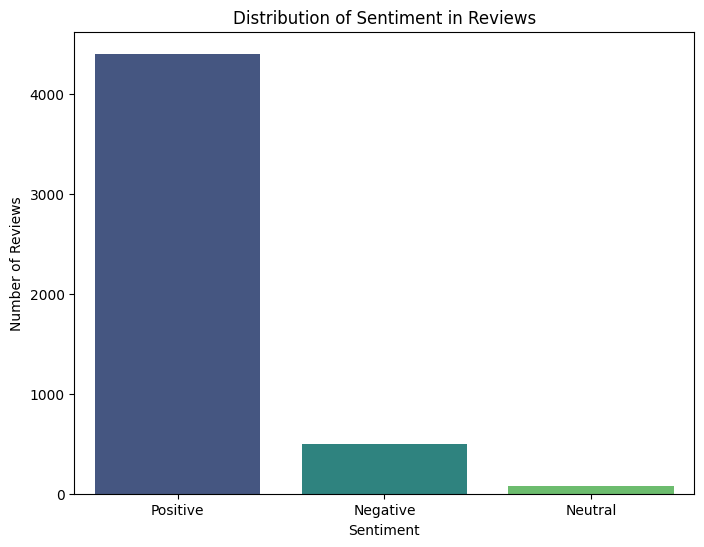

In [21]:
# Bar chart for sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df_selected, palette='viridis')
plt.title('Distribution of Sentiment in Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

### Chart 2: Percentage Distribution of Sentiments

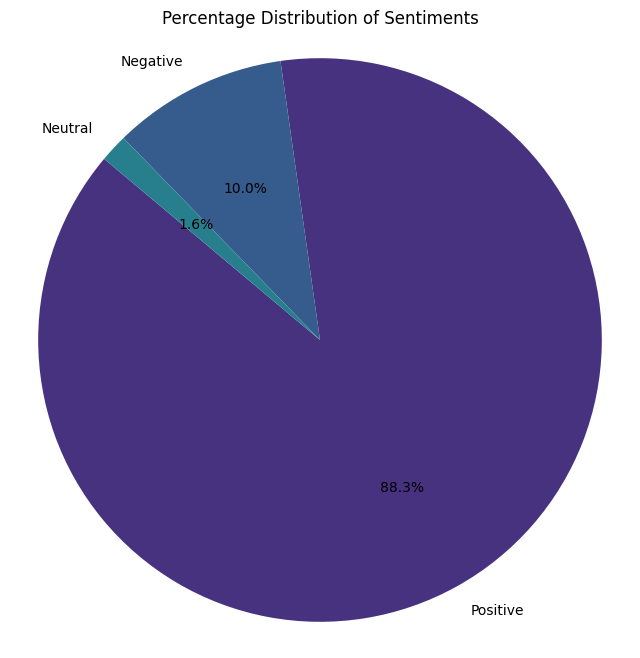

In [22]:
# Pie chart for sentiment distribution
sentiment_counts = df_selected['sentiment'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
plt.title('Percentage Distribution of Sentiments')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Chart 3: Review Score vs. Sentiment

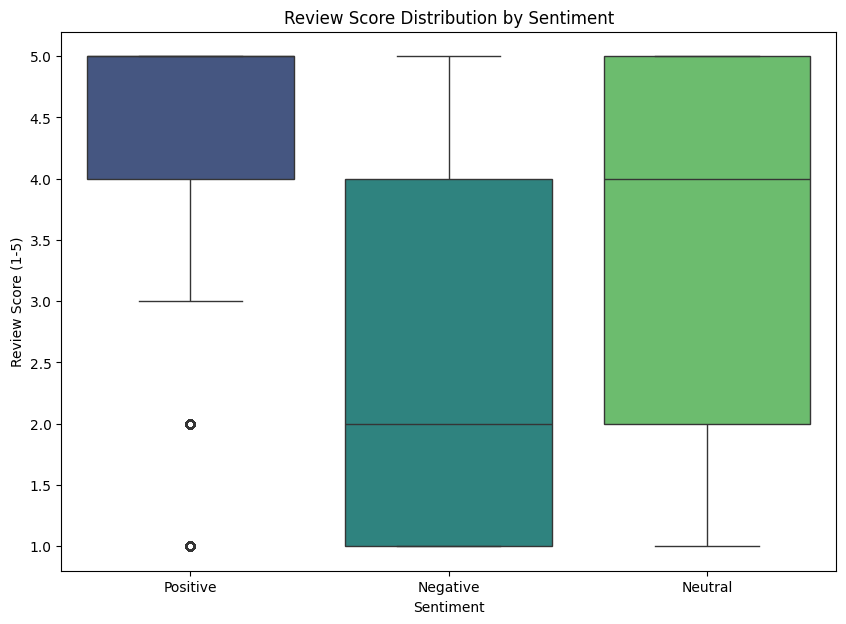

In [25]:
# Box plot to compare review score with sentiment
plt.figure(figsize=(10, 7))
sns.boxplot(x='sentiment', y='Score', data=df_selected, palette='viridis')
plt.title('Review Score Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Score (1-5)')
plt.show()

### Chart 4: Most Common Words in Negative Reviews

In [27]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary NLTK data (if not already downloaded)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
try:
    word_tokenize('test')
except LookupError:
    nltk.download('punkt')
try:
    # Download punkt_tab as well, which can be required for word_tokenize
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z]', ' ', text)
    # Tokenize words
    words = word_tokenize(text)
    # Remove stop words and single character words
    words = [word for word in words if word not in stop_words and len(word) > 1]
    return words

# Filter for negative reviews
negative_reviews_df = df_selected[df_selected['sentiment'] == 'Negative']

# Apply preprocessing and get all words from negative reviews
all_negative_words = negative_reviews_df['Text'].apply(preprocess_text).explode()

# Count word frequencies
word_counts = Counter(all_negative_words)

# Get the 20 most common words
most_common_words = word_counts.most_common(20)

print("Top 20 most common words in negative reviews:")
for word, count in most_common_words:
    print(f"{word}: {count}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Top 20 most common words in negative reviews:
br: 407
like: 216
product: 167
taste: 142
one: 132
would: 103
food: 101
flavor: 96
chips: 95
even: 85
box: 84
bad: 84
get: 81
buy: 77
tea: 77
tried: 73
amazon: 73
time: 71
really: 65
bag: 62


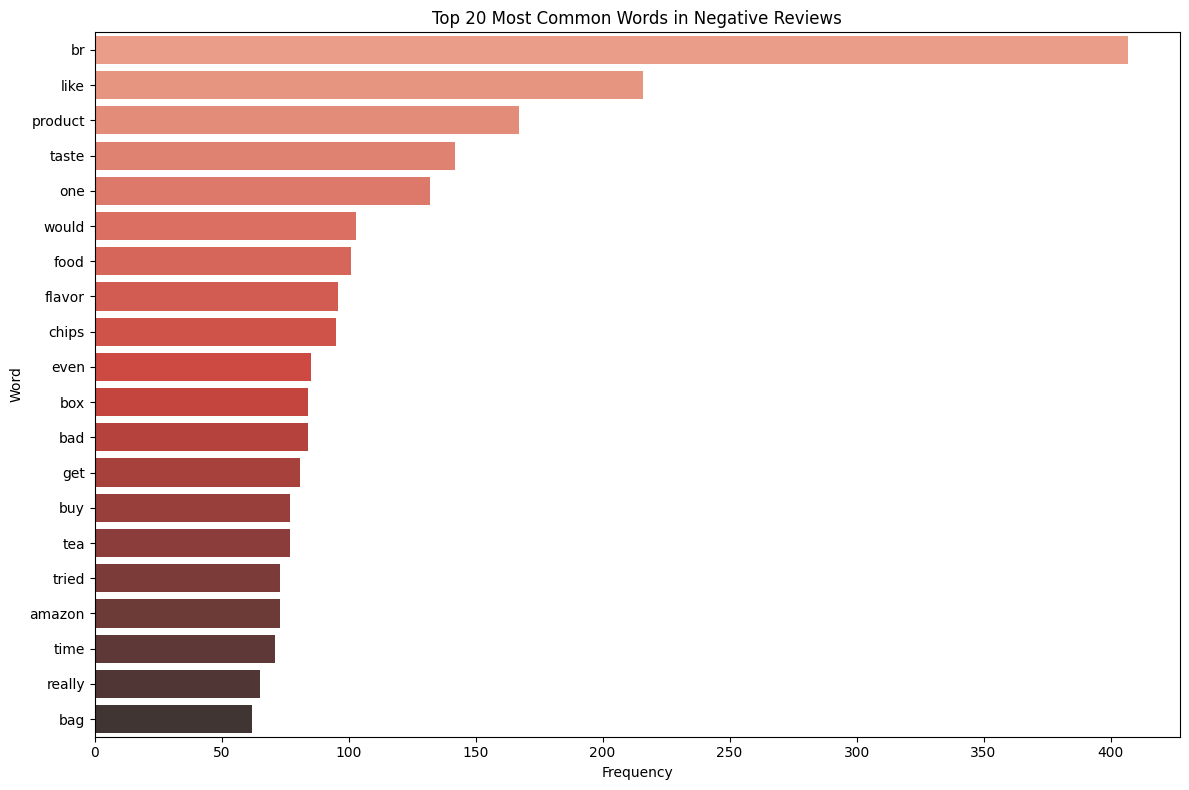

In [28]:
common_words_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=common_words_df, palette='Reds_d')
plt.title('Top 20 Most Common Words in Negative Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

**Task 5 — Insights & Summary**

Based on our analysis:

Approximately **88.35%** (4406 out of 4987) of the reviews are positive, as seen in the sentiment distribution charts. Customers mostly complain about issues related to **taste, product quality, and specific ingredients** in their negative reviews, with terms like 'br', 'like', 'product', 'taste', 'food', and 'flavor' being most common (as shown in the 'Most Common Words in Negative Reviews' chart). What surprised me in the data was that 'Neutral' sentiment reviews still exhibit a relatively high median 'Score' (around 4), suggesting that a lack of strong positive or negative emotion doesn't necessarily equate to a low rating. One recommendation for the business based on these findings is to **closely monitor and address customer feedback regarding taste and product consistency, especially for items frequently mentioned in negative reviews, as these appear to be primary drivers of dissatisfaction.**